In [5]:
# ==========================
# Import Required Libraries
# ==========================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [11]:
# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("../backend/data/ola.csv")

In [4]:
# Display first five rows

df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


In [12]:
# Number of rows and columns

df.shape

(17379, 17)

In [13]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [15]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [16]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['cnt'].head()

0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64

In [20]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

In [21]:
# Load the dataset
df = pd.read_csv("../backend/data/ola.csv")

# Display first 5 rows
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [14]:
df.shape

(17379, 17)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [22]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

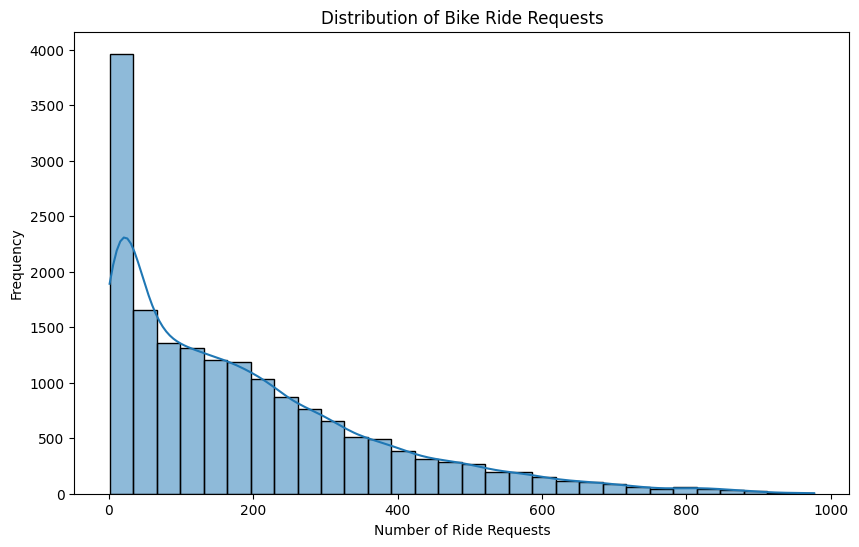

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(df['cnt'], bins=30, kde=True)

plt.title("Distribution of Bike Ride Requests")
plt.xlabel("Number of Ride Requests")
plt.ylabel("Frequency")

plt.show()

In [25]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

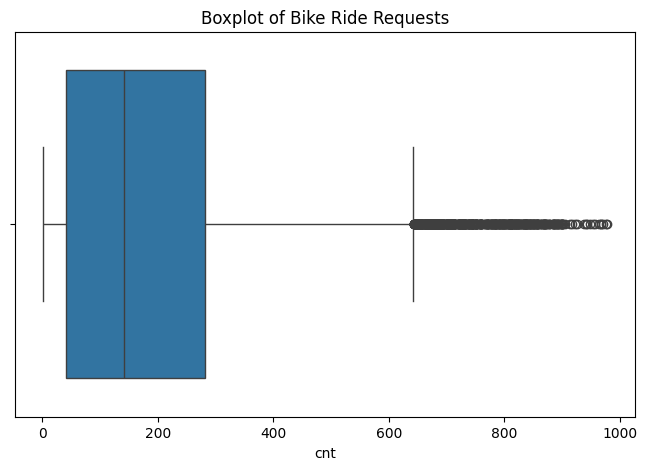

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['cnt'])

plt.title("Boxplot of Bike Ride Requests")

plt.show()

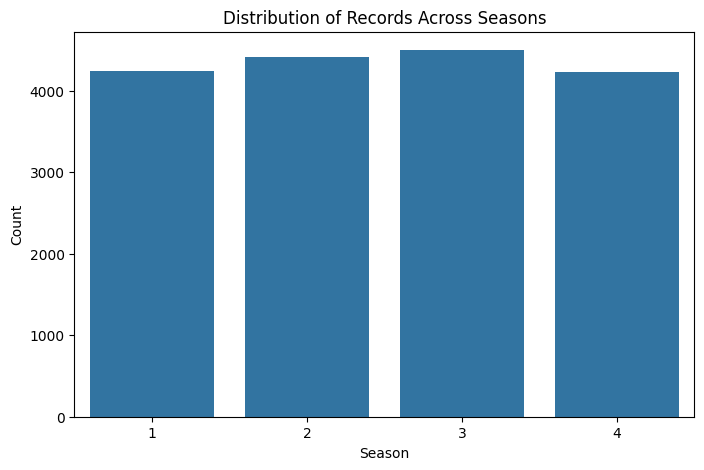

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x='season', data=df)

plt.title("Distribution of Records Across Seasons")
plt.xlabel("Season")
plt.ylabel("Count")

plt.show()


In [28]:
season_labels = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

df["season_name"] = df["season"].map(season_labels)

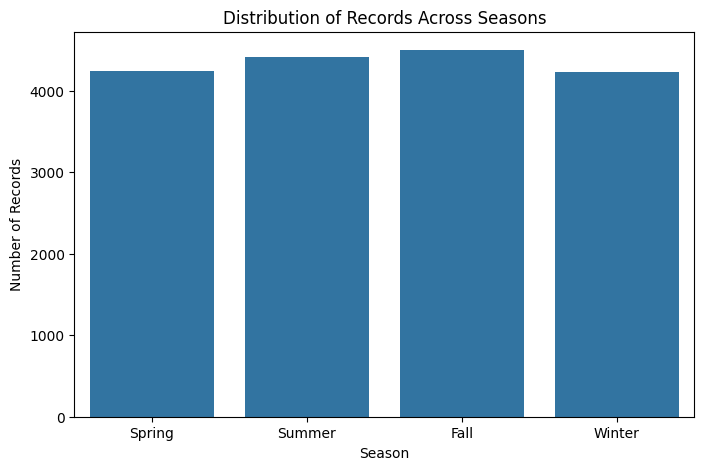

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="season_name",
    data=df,
    order=["Spring", "Summer", "Fall", "Winter"]
)

plt.title("Distribution of Records Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

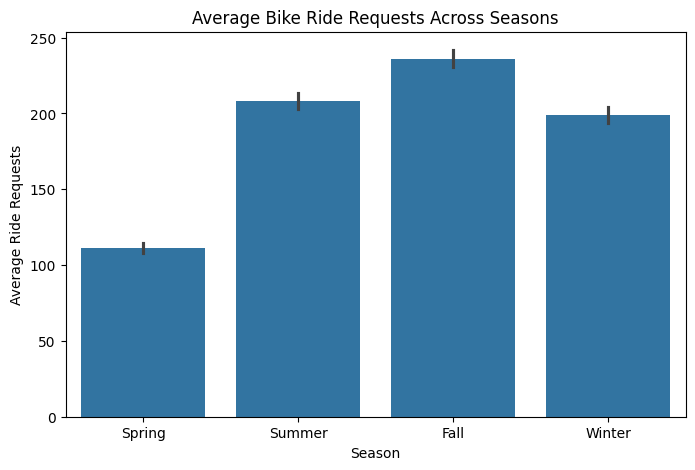

In [30]:
#eda 1
plt.figure(figsize=(8,5))

sns.barplot(
    x="season_name",
    y="cnt",
    data=df,
    order=["Spring", "Summer", "Fall", "Winter"],
    estimator="mean"
)

plt.title("Average Bike Ride Requests Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Ride Requests")

plt.show()

In [31]:
# EDA 2
season_labels = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

df["season_name"] = df["season"].map(season_labels)


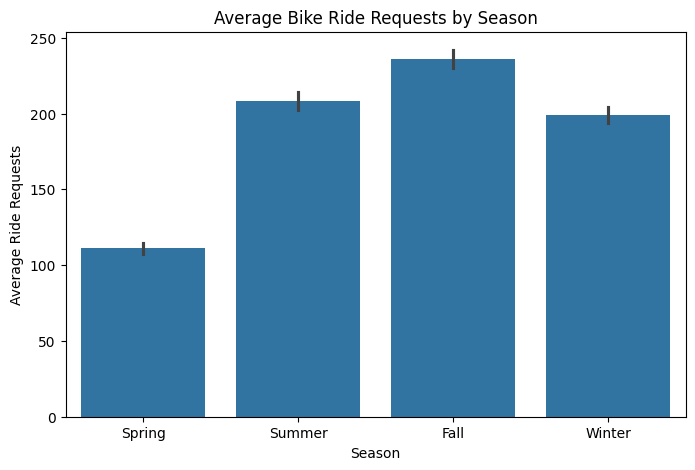

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="season_name",
    y="cnt",
    order=["Spring","Summer","Fall","Winter"]
)

plt.title("Average Bike Ride Requests by Season")
plt.xlabel("Season")
plt.ylabel("Average Ride Requests")

plt.show()

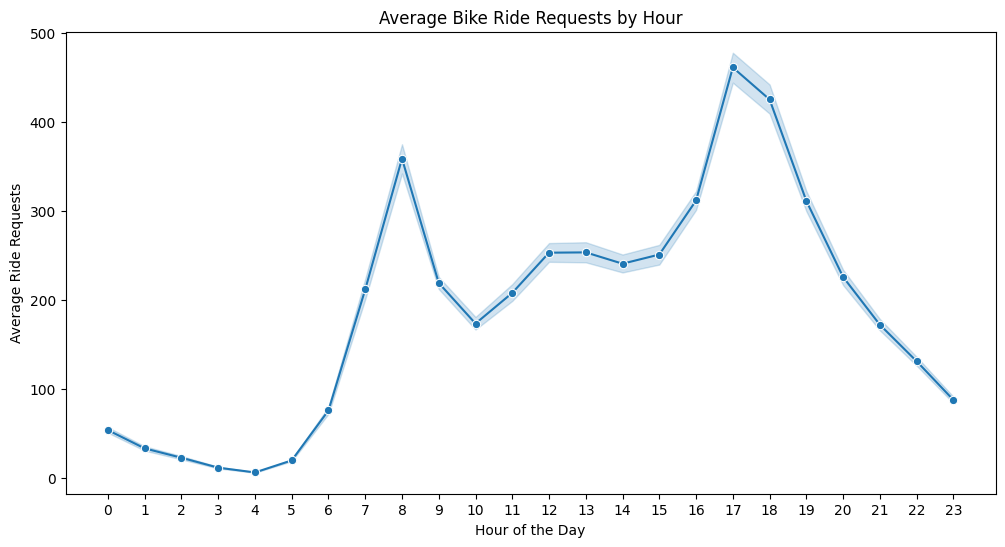

In [33]:
# EDA 3
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="hr",
    y="cnt",
    estimator="mean",
    marker="o"
)

plt.title("Average Bike Ride Requests by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Ride Requests")

plt.xticks(range(0,24))

plt.show()

In [34]:
# EDA 4
weather_labels = {
    1: "Clear",
    2: "Mist",
    3: "Light Snow/Rain",
    4: "Heavy Rain"
}

df["weather_name"] = df["weathersit"].map(weather_labels)

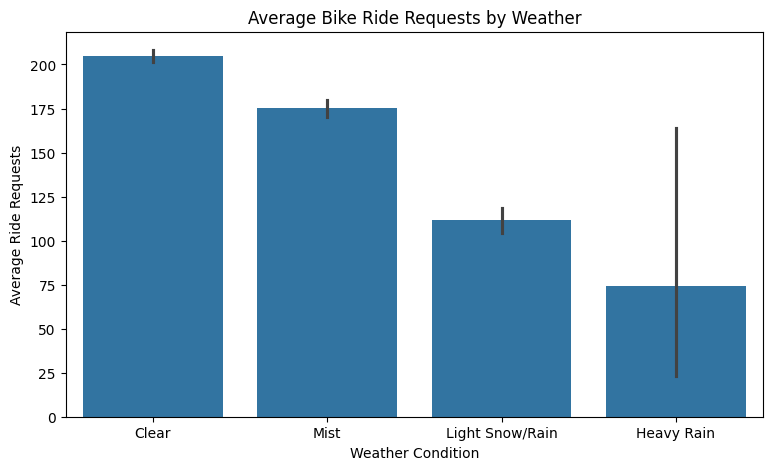

In [35]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df,
    x="weather_name",
    y="cnt"
)

plt.title("Average Bike Ride Requests by Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Average Ride Requests")

plt.show()

### bivariate analysis

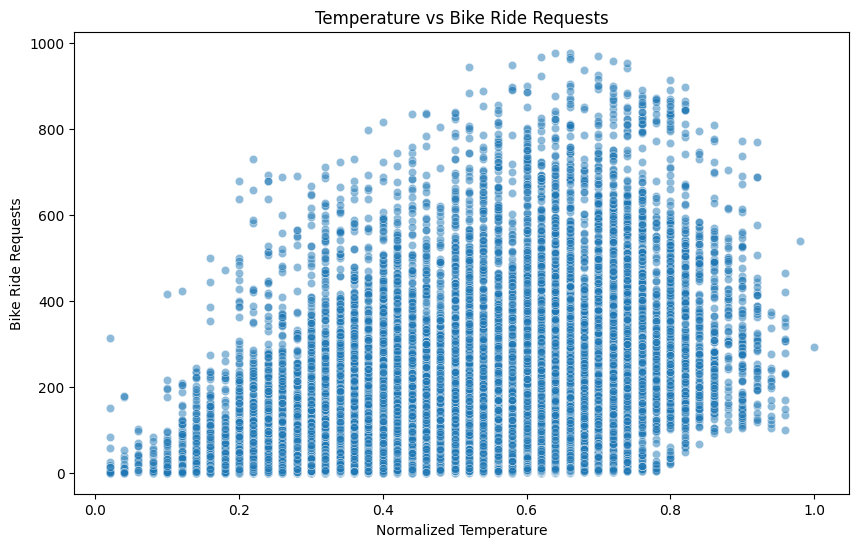

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    alpha=0.5
)

plt.title("Temperature vs Bike Ride Requests")
plt.xlabel("Normalized Temperature")
plt.ylabel("Bike Ride Requests")

plt.show()

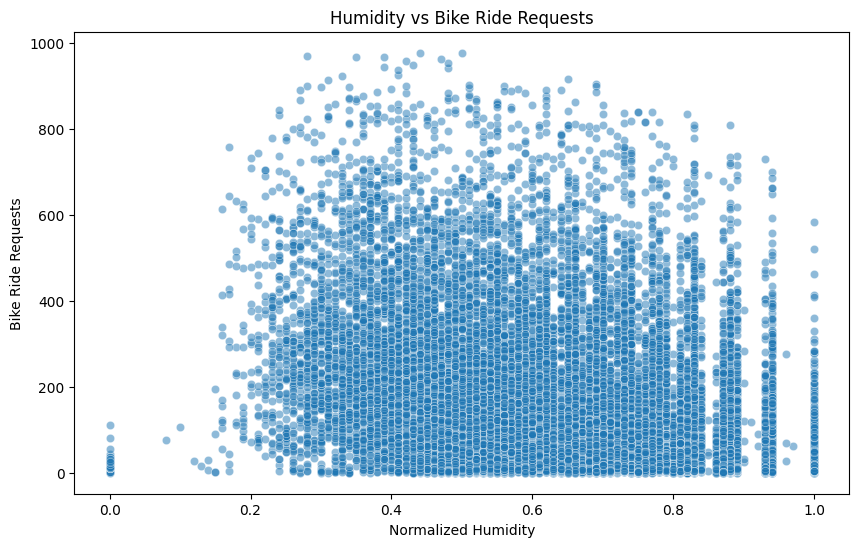

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="hum",
    y="cnt",
    alpha=0.5
)

plt.title("Humidity vs Bike Ride Requests")
plt.xlabel("Normalized Humidity")
plt.ylabel("Bike Ride Requests")

plt.show()

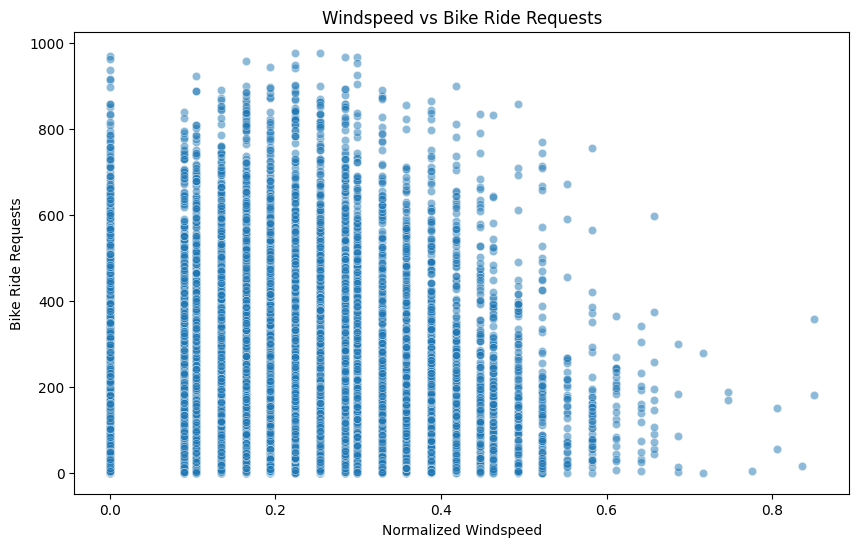

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="windspeed",
    y="cnt",
    alpha=0.5
)

plt.title("Windspeed vs Bike Ride Requests")
plt.xlabel("Normalized Windspeed")
plt.ylabel("Bike Ride Requests")

plt.show()

In [39]:
# eda 5
workingday_labels = {
    0: "Non-Working Day",
    1: "Working Day"
}

df["workingday_name"] = df["workingday"].map(workingday_labels)

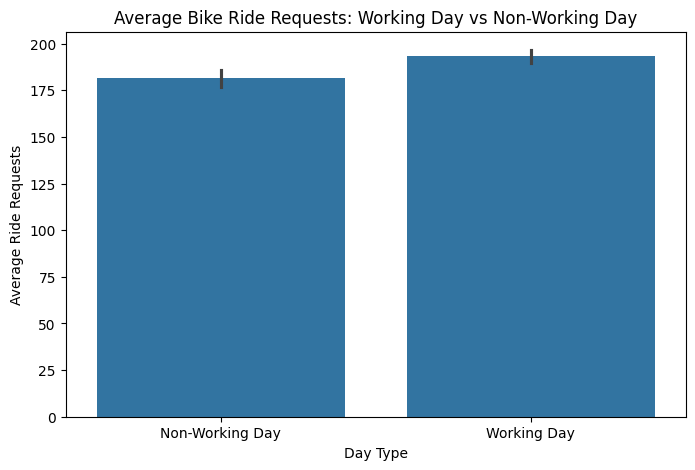

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="workingday_name",
    y="cnt"
)

plt.title("Average Bike Ride Requests: Working Day vs Non-Working Day")
plt.xlabel("Day Type")
plt.ylabel("Average Ride Requests")

plt.show()

In [41]:
# eda 6
month_labels = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",
    5:"May",6:"Jun",7:"Jul",8:"Aug",
    9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

df["month_name"] = df["mnth"].map(month_labels)

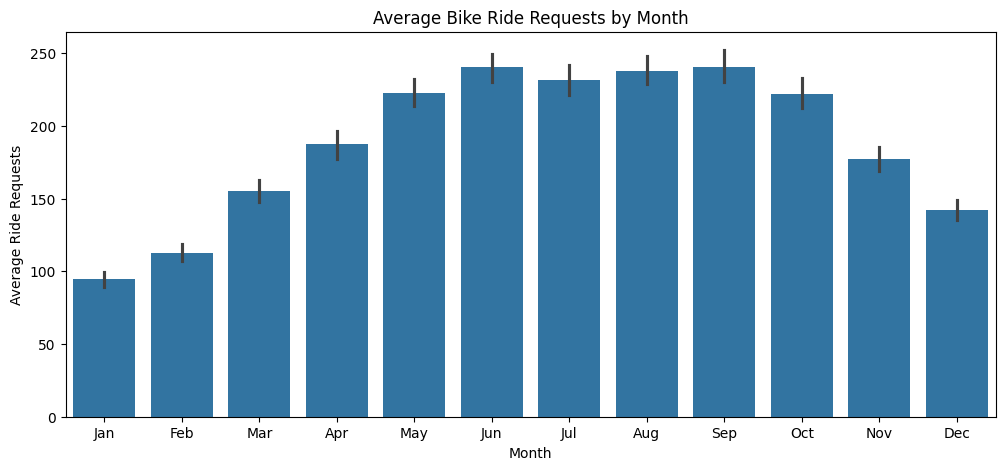

In [42]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="month_name",
    y="cnt",
    order=["Jan","Feb","Mar","Apr","May","Jun",
           "Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.title("Average Bike Ride Requests by Month")
plt.xlabel("Month")
plt.ylabel("Average Ride Requests")

plt.show()

In [43]:
# eda 7
weekday_labels = {
    0:"Sunday",
    1:"Monday",
    2:"Tuesday",
    3:"Wednesday",
    4:"Thursday",
    5:"Friday",
    6:"Saturday"
}

df["weekday_name"] = df["weekday"].map(weekday_labels)

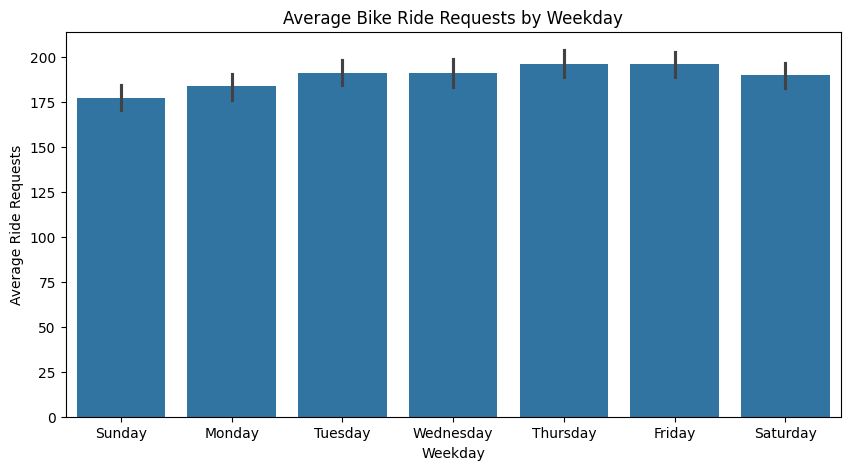

In [44]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="weekday_name",
    y="cnt",
    order=["Sunday","Monday","Tuesday",
           "Wednesday","Thursday","Friday","Saturday"]
)

plt.title("Average Bike Ride Requests by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Ride Requests")

plt.show()

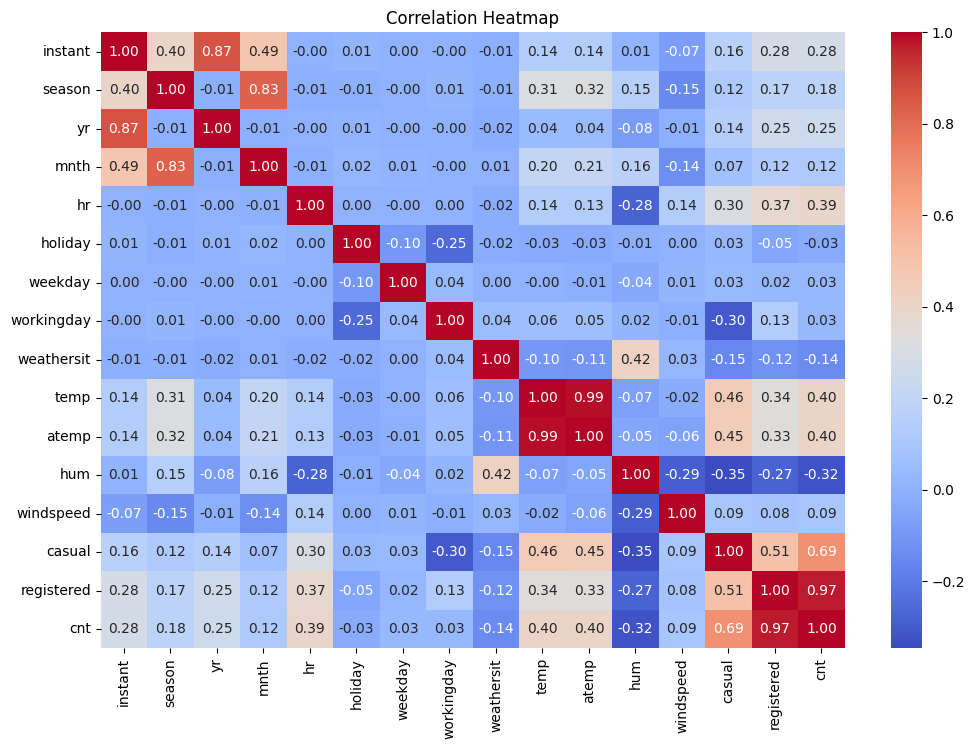

In [45]:
# eda 8
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

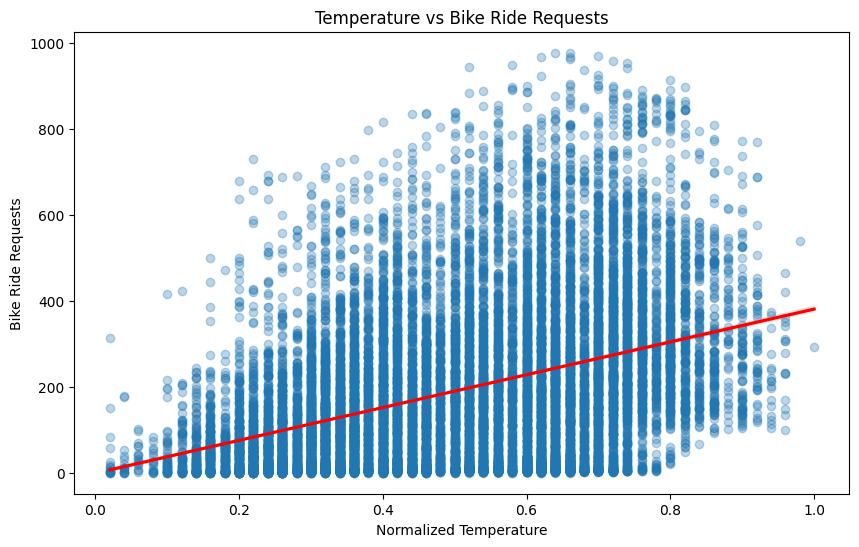

In [46]:
# EDA 9

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="temp",
    y="cnt",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Temperature vs Bike Ride Requests")
plt.xlabel("Normalized Temperature")
plt.ylabel("Bike Ride Requests")

plt.show()

In [47]:
X = df.drop(
    columns=[
        "instant",
        "dteday",
        "casual",
        "registered",
        "cnt",
        "season_name",
        "weather_name",
        "workingday_name",
        "month_name",
        "weekday_name"
    ]
)

y = df["cnt"]

# x contains the input features
# y contains the output  

In [48]:
X.head()

# x contains the independent variables (features) used for prediction

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [49]:
y.head()

# y contains the dependent variable (cnt, which is the value we want the model to predict)

0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64

In [50]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (17379, 12)
Shape of y: (17379,)


In [51]:
# train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# test_size =0.2 means -- 80% is trainig data 
#                      -- 20% is the testing data

In [52]:
# checking the shapes

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(13903, 12)
(3476, 12)
(13903,)
(3476,)


In [53]:
# feature scaling of the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# machine learning model building



### linear regression


In [54]:
from sklearn.linear_model import LinearRegression

In [55]:
lr_model = LinearRegression()

In [56]:
lr_model.fit(X_train_scaled, y_train)

# fit() means --- train the model using the training data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
# make predictions

y_pred = lr_model.predict(X_test_scaled)

In [58]:
# compare predictions

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
12830,425,450.296525
8688,88,204.674145
7091,4,57.297891
12230,526,383.363764
431,13,-20.341232
1086,32,7.344152
11605,706,344.316429
7983,26,25.443648
10391,2,122.215874
7046,21,99.447594


In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [60]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 104.80335089554427


In [61]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 139.2114519989348


In [62]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.3879811583139132


In [63]:
print("Linear Regression Performance")
print("-" * 35)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 104.80
RMSE : 139.21
R²   : 0.3880


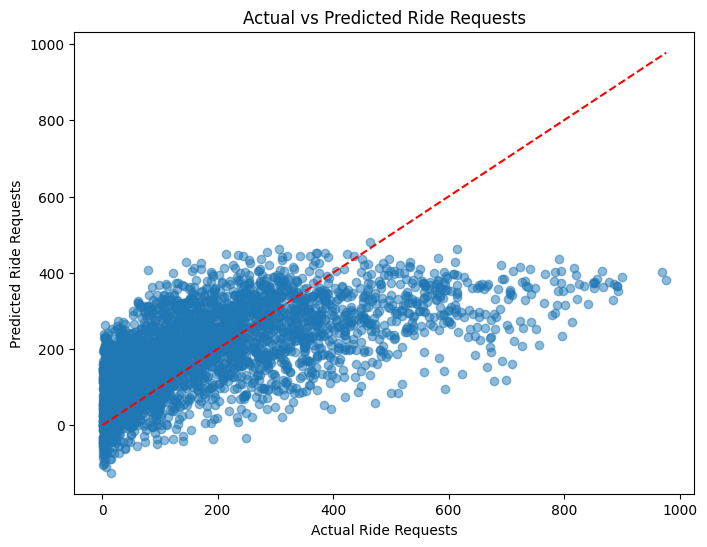

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Ride Requests")
plt.ylabel("Predicted Ride Requests")
plt.title("Actual vs Predicted Ride Requests")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()

### Observation

The Linear Regression model achieved an R² score of **0.3880**, indicating that it explains approximately **38.8%** of the variation in bike ride demand.

The relatively high MAE and RMSE values suggest that the model struggles to accurately predict demand, particularly during periods of high bike usage.

Since bike rental demand depends on complex, non-linear relationships between features such as hour, weather, and season, Linear Regression is not sufficient for this problem.

### decision tree regressor 

In [65]:
from sklearn.tree import DecisionTreeRegressor

In [66]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [67]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [68]:
y_pred_dt = dt_model.predict(X_test)

In [69]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-" * 35)

print(f"MAE  : {mae_dt:.2f}")
print(f"RMSE : {rmse_dt:.2f}")
print(f"R²   : {r2_dt:.4f}")

Decision Tree Performance
-----------------------------------
MAE  : 34.18
RMSE : 58.25
R²   : 0.8929


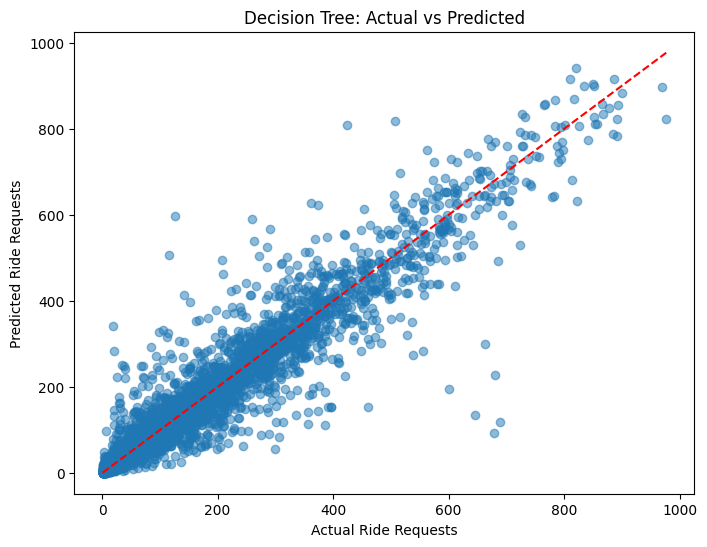

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_dt, alpha=0.5)

plt.xlabel("Actual Ride Requests")
plt.ylabel("Predicted Ride Requests")
plt.title("Decision Tree: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()

### Observation

The Decision Tree Regressor achieved an R² score of **0.8929**, indicating that it explains approximately **89.3%** of the variation in bike ride demand.

Compared to Linear Regression, the Decision Tree significantly reduced both MAE and RMSE, demonstrating its ability to capture the non-linear relationships present in the dataset.

The Actual vs Predicted scatter plot also shows that most predictions lie close to the ideal diagonal line, indicating strong predictive performance.

### Random Forest Regressor


In [71]:
from sklearn.ensemble import RandomForestRegressor

In [72]:
rf_model = RandomForestRegressor(
    n_estimators=75,
    random_state=42,
    n_jobs=-1
)

In [73]:
rf_model.fit(X_train, y_train)

,n_estimators,75
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred_rf = rf_model.predict(X_test)

In [75]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 24.94
RMSE : 42.09
R²   : 0.9441


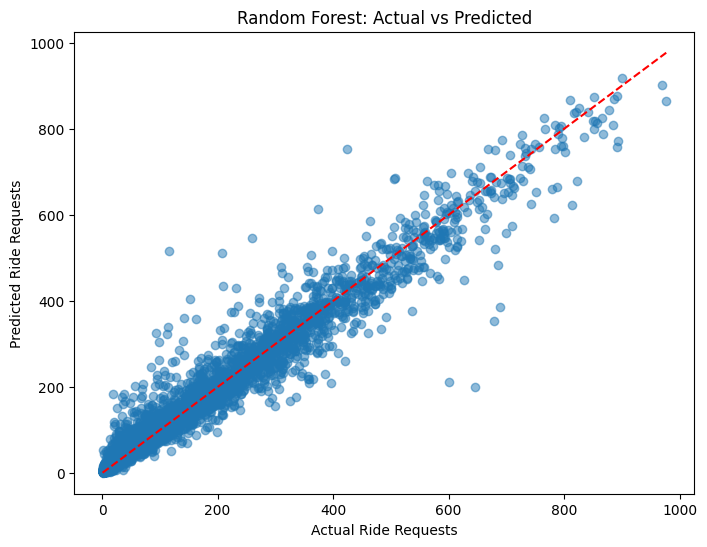

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual Ride Requests")
plt.ylabel("Predicted Ride Requests")
plt.title("Random Forest: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()

In [77]:
import joblib

joblib.dump(rf_model, "bike_demand_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [78]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### feature importance


In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with feature names and their importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
3           hr    0.611604
8         temp    0.118994
1           yr    0.080791
6   workingday    0.058338
10         hum    0.026755
9        atemp    0.021916
0       season    0.021428
7   weathersit    0.018281
2         mnth    0.016650
5      weekday    0.012408
11   windspeed    0.010273
4      holiday    0.002562


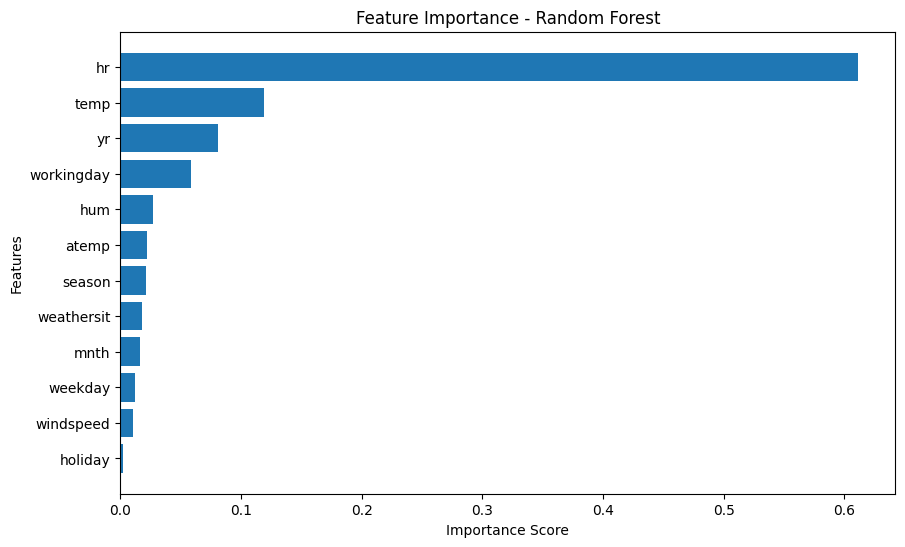

In [80]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()